In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import matplotlib.pyplot as plt

from src.data.market_loader import MarketLoader

from src.curves.curve_snapshot import CurveSnapshot
from src.curves.bootstrap.bootstrap_engine import BootstrapCurveEngine
from src.curves.projection_curve import ProjectionCurve
from src.curves.zero_curve import ZeroCurve
from src.curves.simulator.hull_white_2factor import HullWhite2FactorSimulator
from src.curves.simulator.hull_white_2factor_pricer import HullWhite2FactorPricer

from src.instruments.instrument_builder import InstrumentBuilder

from src.trades.interest_rate_swap import InterestRateSwap

from src.pricing.hull_white_2factor_swap_pricer import HullWhite2FactorSwapPricer

from src.risk.exposure.stochastic_exposure_engine_2factor import MonteCarloExposureEngine2Factor

In [2]:
# downloading market curves
market_loader = MarketLoader()
market_curves = market_loader.market_loader_pipeline()

# downloading swap curves
swap_loader = MarketLoader()
swap_curves = swap_loader.swap_loader_pipeline()

treasury curve dataset already downloaded..
sofr curve dataset already downloaded..
futures curve dataset already downloaded..
estr curve dataset already downloaded..
usd_ois curve dataset already downloaded..
eur_ois curve dataset already downloaded..


In [3]:
### create curve snapshots
# SOFR snapshot
sofr_df = market_curves['sofr']

latest_date = sofr_df.index[-1]
latest_sofr_curve = sofr_df.iloc[-1]

sofr_snapshot = CurveSnapshot.snap_from_df_row(
    curve_name = 'sofr',
    as_of_date = latest_date,
    curve_row = latest_sofr_curve
)

# Futures snapshot
future_df = market_curves['futures']
latest_futures_curve = future_df.iloc[-1]

futures_snapshot = CurveSnapshot.snap_from_df_row(
    curve_name = 'futures',
    as_of_date = latest_date,
    curve_row = latest_futures_curve
)

# OIS snapshot
ois_df = swap_curves['usd_ois']

latest_swap_date = ois_df.index[-1]
latest_swap_curve = ois_df.iloc[-1]

ois_snapshot = CurveSnapshot.snap_from_df_row(
    curve_name = 'usd_ois',
    as_of_date = latest_swap_date,
    curve_row = latest_swap_curve
)

In [4]:
### create instruments from curve snapshot
# deposits
deposit_instruments = InstrumentBuilder.build_deposit_instruments(snapshot = sofr_snapshot)

# futures
future_instruments = InstrumentBuilder.build_future_instruments(snapshot = futures_snapshot)

# ois
ois_instruments = InstrumentBuilder.build_ois_instruments(snapshot = ois_snapshot)

### discount, projection and zero curve builder
# bootstrapping engine for generating the discount curve
all_instruments = deposit_instruments + future_instruments + ois_instruments

engine = BootstrapCurveEngine()

discount_curve = engine.bootstrap(
    snapshot = sofr_snapshot,
    instruments = all_instruments
)

# projection curve
projection_curve = ProjectionCurve(discount_curve = discount_curve)

# zero curve
zero_curve = ZeroCurve(discount_curve = discount_curve)

In [5]:
# sample IRS trade objects
IR_swap = InterestRateSwap(
    notional = 1_000_000,
    maturity = 3.0,
    fixed_rate = 3.40,
    pay_fixed = True
)

In [6]:
### HW 2-factor exposure risk analytics
# short rate
r0 = zero_curve.get_zero_rate(maturity = 0.25)

# hw simulator
hw_simulator = HullWhite2FactorSimulator(
    r0 = r0,
    random_seed = 2
)

# hw pricer
hw_pricer = HullWhite2FactorPricer(zero_curve = zero_curve)

# hw 2-factor swap pricer
hw_swap_pricer = HullWhite2FactorSwapPricer(hw_pricer = hw_pricer)

# hw 2-factor exposure engine
mc_hw2f_engine = MonteCarloExposureEngine2Factor(
    pricer = hw_swap_pricer,
    simulator = hw_simulator
)

In [7]:
# expected exposure
ee = mc_hw2f_engine.expected_exposure(
    swap = IR_swap, 
    n_paths = 250
)
ee

,Times,EE
0,0.00,7858.425573
1,0.25,9973.485781
2,0.50,10470.307863
3,0.75,10156.479085
4,1.00,9207.764278
5,1.25,9130.352023
6,1.50,8731.886072
7,1.75,7378.961374
8,2.00,6126.808717
9,2.25,4597.670638


In [8]:
# expected negative exposure
ene = mc_hw2f_engine.expected_negative_exposure(
    swap = IR_swap,
    n_paths = 250
)
ene

,Times,ENE
0,0.00,-0.000000
1,0.25,3002.923668
2,0.50,5208.445948
3,0.75,6281.588243
4,1.00,6906.926345
5,1.25,7019.235878
6,1.50,6574.241148
7,1.75,6146.751806
8,2.00,5474.848593
9,2.25,4121.985238


In [9]:
# potential future exposure
perc = 95.0

pfe = mc_hw2f_engine.potential_future_exposure(
    swap = IR_swap,
    percentile = perc,
    n_paths = 250
)
pfe

,Times,PFE_95%
0,0.00,7858.425573
1,0.25,28474.616749
2,0.50,36501.384490
3,0.75,37461.708532
4,1.00,34308.013617
5,1.25,38895.580524
6,1.50,36109.616502
7,1.75,29994.849212
8,2.00,21955.188252
9,2.25,19959.148504


In [10]:
# expected positive exposure
epe = mc_hw2f_engine.expected_positive_exposure(
    swap = IR_swap,
    n_paths = 250
)
epe

6506.385825087285

In [11]:
mc_hw2f_engine.mc_exposure_report(swap = IR_swap, n_paths = 250)

,Times,EE,ENE,PFE_95%,EffectiveEE
0,0.00,7858.425573,-0.000000,7858.425573,7858.425573
1,0.25,10095.945731,2329.622046,28400.502920,8851.139771
2,0.50,9885.929128,3592.296309,33529.650908,10556.959952
3,0.75,10233.390625,4488.371897,35598.005679,11081.626849
4,1.00,9761.049745,5038.518805,33803.469669,11081.626849
5,1.25,9934.444287,5292.422917,33262.227492,11081.626849
6,1.50,8573.953761,5162.844724,32278.677380,11081.626849
7,1.75,7146.848630,5196.698367,29826.908617,11081.626849
8,2.00,5617.419216,4701.717211,24249.561508,11081.626849
9,2.25,4432.696858,3596.300993,19376.068214,11081.626849


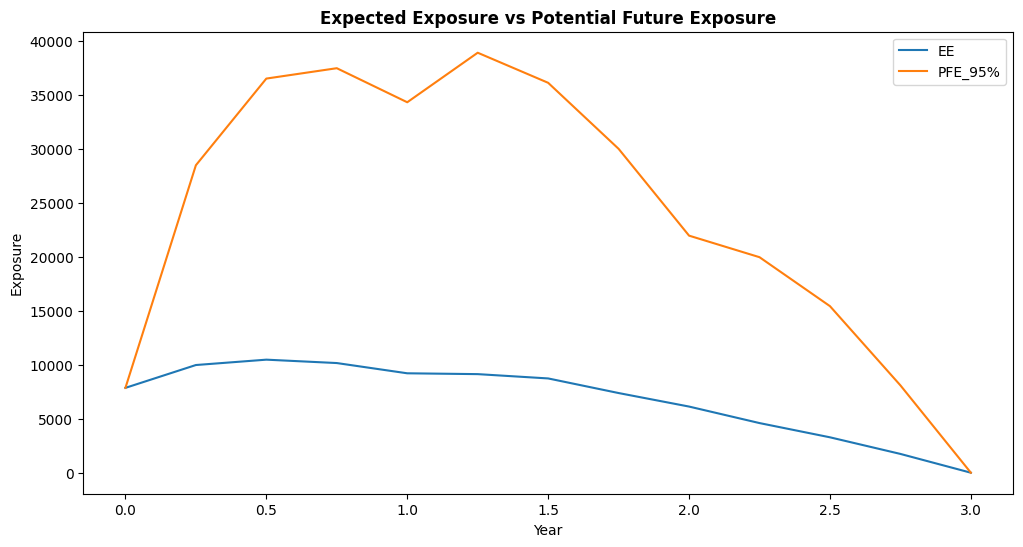

In [12]:
# plot expected exposure vs potential future exposue
plt.figure(figsize = (12, 6))

plt.plot(ee['Times'], ee['EE'], label = 'EE')
plt.plot(pfe['Times'], pfe[f'PFE_{perc:.0f}%'], label = f'PFE_{perc:.0f}%')

plt.title('Expected Exposure vs Potential Future Exposure', fontweight = 'bold')
plt.xlabel('Year')
plt.ylabel('Exposure')
plt.legend(loc = 'best')
plt.show()

In [13]:
# effective expected exposure & effective EPE
effective_ee = mc_hw2f_engine.effective_expected_exposure(
    swap = IR_swap,
    n_paths = 250,
    steps_per_year = 4
)

effective_epe = mc_hw2f_engine.effective_expected_positive_exposure(
    swap = IR_swap,
    n_paths = 250,
    steps_per_year = 4
)

print(f'Effective EPE: {effective_epe:.1f}')

display(effective_ee)

Effective EPE: 10048.6


,Times,EffectiveEE
0,0.00,7858.425573
1,0.25,7858.425573
2,0.50,8821.657711
3,0.75,8821.657711
4,1.00,8821.657711
5,1.25,8821.657711
6,1.50,8821.657711
7,1.75,8821.657711
8,2.00,8821.657711
9,2.25,8821.657711


In [14]:
# full exposure report
mc_hw2f_engine.full_exposure_report(
    swap = IR_swap,
    percentile = 95,
    n_paths = 250,
    steps_per_year = 4
)

,Metric,Value
0,Current Exposure,7858.425573
1,Peak EE,10821.925765
2,Peak ENE,6146.358062
3,Peak PFE,36464.262978
4,EPE,6425.158389
5,Effective EPE,9564.383471
